## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import json
from sklearn.utils import resample
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
import nltk
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [2]:
def load_sample(file_path, sample_size=75000):

    data = []
    # Open the file and read the specified number of lines
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i == sample_size:
                break
            data.append(json.loads(line))  # Parse each line as JSON
    return pd.DataFrame(data)

# Specify the file path and sample size
file_path = 'yelp_academic_dataset_review.json'
sample_size = 75000  

# Load a sample of reviews
reviews_sample = load_sample(file_path, sample_size=sample_size)

# Display information about the sampled data
print(reviews_sample.info())
print(reviews_sample.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   review_id    75000 non-null  object 
 1   user_id      75000 non-null  object 
 2   business_id  75000 non-null  object 
 3   stars        75000 non-null  float64
 4   useful       75000 non-null  int64  
 5   funny        75000 non-null  int64  
 6   cool         75000 non-null  int64  
 7   text         75000 non-null  object 
 8   date         75000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 5.1+ MB
None
                review_id                 user_id             business_id  \
0  KU_O5udG6zpxOg-VcAEodg  mh_-eMZ6K5RLWhZyISBhwA  XQfwVwDr-v0ZS3_CbbE5Xw   
1  BiTunyQ73aT9WBnpR9DZGw  OyoGAe7OKpv6SyGZT5g77Q  7ATYjTIgM3jUlt4UM3IypQ   
2  saUsX_uimxRlCVr67Z4Jig  8g_iMtfSiwikVnbP2etR0A  YjUWPpI6HXG530lwP-fb2A   
3  AqPFMleE6RsU23_auESxiA  _7bHUi9Uuf5__HHc_Q8guQ  kxX2

## Data Preprocessing

In [3]:
# Check for null values in the dataset
print(reviews_sample.isnull().sum())

review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64


In [4]:
# Extract 'text' (review text) and 'stars' (rating) columns
if 'text' in reviews_sample.columns and 'stars' in reviews_sample.columns:
    reviews_filtered = reviews_sample[['text', 'stars']]

    # Display information about the filtered DataFrame
    print(reviews_filtered.info())
    print(reviews_filtered.head())
else:
    print("The required columns 'text' and 'stars' are not in the dataset.")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   text    75000 non-null  object 
 1   stars   75000 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.1+ MB
None
                                                text  stars
0  If you decide to eat here, just be aware it is...    3.0
1  I've taken a lot of spin classes over the year...    5.0
2  Family diner. Had the buffet. Eclectic assortm...    3.0
3  Wow!  Yummy, different,  delicious.   Our favo...    5.0
4  Cute interior and owner (?) gave us tour of up...    4.0


Star Rating Distribution:
stars
5.0    33327
4.0    19064
3.0     8483
1.0     8157
2.0     5969
Name: count, dtype: int64


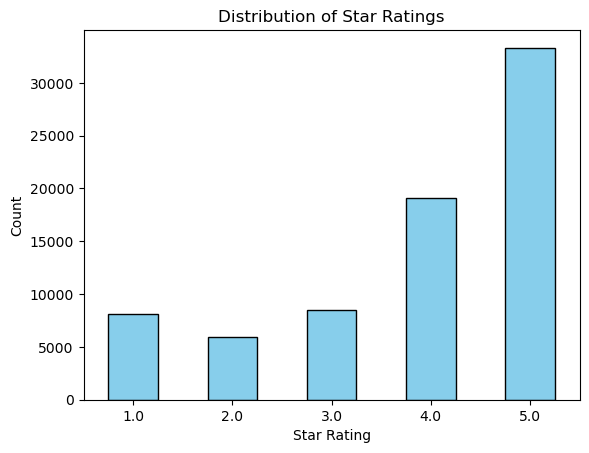

In [5]:
# Check the distribution of star ratings
star_distribution = reviews_filtered['stars'].value_counts()

# Display the category distribution
print("Star Rating Distribution:")
print(star_distribution)

# visualize the distribution
star_distribution.sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribution of Star Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


Rating Category Distribution:
rating_category
Positive    52391
Negative    14126
Neutral      8483
Name: count, dtype: int64


C:\Users\JISNA\AppData\Local\Temp\ipykernel_19068\978430912.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_filtered['rating_category'] = reviews_filtered['stars'].apply(map_star_rating)


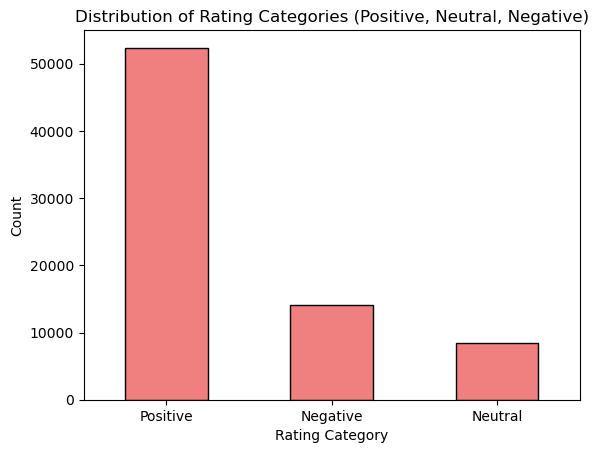

In [6]:
# Map the star ratings to categories
def map_star_rating(stars):
    if stars >= 4:
        return 'Positive'
    elif stars == 3:
        return 'Neutral'
    else:
        return 'Negative'

# Apply the mapping function to the 'stars' column
reviews_filtered['rating_category'] = reviews_filtered['stars'].apply(map_star_rating)

# Check the distribution of each category (Positive, Neutral, Negative)
category_distribution = reviews_filtered['rating_category'].value_counts()

# Display the category distribution
print("Rating Category Distribution:")
print(category_distribution)

# Optionally, visualize the distribution
category_distribution.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title("Distribution of Rating Categories (Positive, Neutral, Negative)")
plt.xlabel("Rating Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


Balanced Rating Category Distribution:
rating_category
Negative    8483
Positive    8483
Neutral     8483
Name: count, dtype: int64


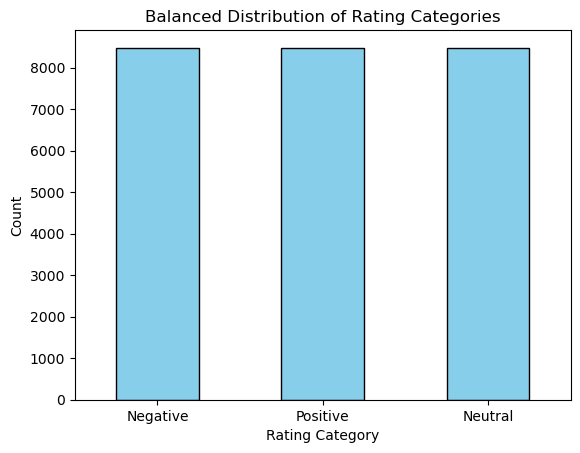

In [7]:
# Separate data by category
positive_reviews = reviews_filtered[reviews_filtered['rating_category'] == 'Positive']
negative_reviews = reviews_filtered[reviews_filtered['rating_category'] == 'Negative']
neutral_reviews = reviews_filtered[reviews_filtered['rating_category'] == 'Neutral']

# Determine the size to balance (use the smallest category size)
min_size = min(len(positive_reviews), len(negative_reviews), len(neutral_reviews))

# Resample each category to the same size
positive_balanced = resample(positive_reviews, replace=False, n_samples=min_size, random_state=42)
negative_balanced = resample(negative_reviews, replace=False, n_samples=min_size, random_state=42)
neutral_balanced = resample(neutral_reviews, replace=False, n_samples=min_size, random_state=42)

# Combine the balanced data into a single DataFrame
reviews_balanced = pd.concat([positive_balanced, negative_balanced, neutral_balanced])

# Shuffle the balanced dataset
reviews_balanced = reviews_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the new distribution
print("Balanced Rating Category Distribution:")
print(reviews_balanced['rating_category'].value_counts())

# Optional: Visualize the balanced distribution
reviews_balanced['rating_category'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Balanced Distribution of Rating Categories")
plt.xlabel("Rating Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


In [8]:
from sklearn.model_selection import train_test_split

# Split the balanced data into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    reviews_balanced['text'], 
    reviews_balanced['rating_category'], 
    test_size=0.2, 
    random_state=42, 
    stratify=reviews_balanced['rating_category']  # Maintain balanced distribution in both sets
)

# Check the sizes of the splits
print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

# Verify the category distribution in training and test sets
print("\nTraining set distribution:")
print(y_train.value_counts())

print("\nTest set distribution:")
print(y_test.value_counts())


Training set size: 20359
Test set size: 5090

Training set distribution:
rating_category
Negative    6787
Positive    6786
Neutral     6786
Name: count, dtype: int64

Test set distribution:
rating_category
Positive    1697
Neutral     1697
Negative    1696
Name: count, dtype: int64


### Lower case Transformation

In [14]:
# Apply lowercase transformation to the 'text' column
X_train = X_train.str.lower()
X_test = X_test.str.lower()

# Verify the transformation
print("Sample transformed training data:")
print(X_train.head())


Sample transformed training data:
2504     so so disappointing. went there twice and each...
10891    not really worth the price or your time. took ...
6713     lots of reviews about this place mentioned the...
5333     very unfriendly to people with dietary restric...
19096    i have eaten here a number of times and the fo...
Name: text, dtype: object


### Tokenization

In [15]:
from nltk.tokenize import word_tokenize

# Download NLTK data (run this once)
nltk.download('punkt')

# Define preprocessing function for tokenization and punctuation removal
def preprocess_text_tokenization_punctuation(text):
    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    # Tokenize the text
    tokens = word_tokenize(text)
    return tokens

# Apply preprocessing to training and test sets
X_train_tokens = X_train.apply(preprocess_text_tokenization_punctuation)
X_test_tokens = X_test.apply(preprocess_text_tokenization_punctuation)

# Verify the transformation
print("Sample tokenized training data:")
print(X_train_tokens.head())


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\JISNA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Sample tokenized training data:
2504     [so, so, disappointing, went, there, twice, an...
10891    [not, really, worth, the, price, or, your, tim...
6713     [lots, of, reviews, about, this, place, mentio...
5333     [very, unfriendly, to, people, with, dietary, ...
19096    [i, have, eaten, here, a, number, of, times, a...
Name: text, dtype: object


### Stop word removal

In [16]:
# Download NLTK stopwords (run this once)
nltk.download('stopwords')

# Get the English stopwords set
stop_words = set(stopwords.words('english'))

# Define function to remove stopwords
def remove_stopwords(tokens):
    # Remove tokens that are in the stop_words set
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
    return filtered_tokens

# Apply stopword removal to tokenized training and test sets
X_train_tokens_no_stopwords = X_train_tokens.apply(remove_stopwords)
X_test_tokens_no_stopwords = X_test_tokens.apply(remove_stopwords)

# Verify the transformation
print("Sample data after stopword removal:")
print(X_train_tokens_no_stopwords.head())


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\JISNA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Sample data after stopword removal:
2504     [disappointing, went, twice, time, said, id, n...
10891    [really, worth, price, time, took, combined, l...
6713     [lots, reviews, place, mentioned, wonderful, o...
5333     [unfriendly, people, dietary, restrictionsalle...
19096    [eaten, number, times, food, phenomenal, every...
Name: text, dtype: object


### Stemming

In [17]:
# Initialize the stemmer
stemmer = PorterStemmer()

# Define function for stemming
def stem_tokens(tokens):
    # Apply stemming to each token
    return [stemmer.stem(word) for word in tokens]

# Apply stemming to tokenized training and test sets
X_train_tokens_stemmed = X_train_tokens_no_stopwords.apply(stem_tokens)
X_test_tokens_stemmed = X_test_tokens_no_stopwords.apply(stem_tokens)

# Verify the transformation
print("Sample data after stemming:")
print(X_train_tokens_stemmed.head())


Sample data after stemming:
2504     [disappoint, went, twice, time, said, id, neve...
10891    [realli, worth, price, time, took, combin, lau...
6713     [lot, review, place, mention, wonder, owner, a...
5333     [unfriendli, peopl, dietari, restrictionsaller...
19096    [eaten, number, time, food, phenomen, everi, t...
Name: text, dtype: object


### Lemmatization

In [18]:
# Download WordNet data (run this once)
nltk.download('wordnet')

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Define function for lemmatization
def lemmatize_tokens(tokens):
    # Apply lemmatization to each token
    return [lemmatizer.lemmatize(word) for word in tokens]

# Apply lemmatization to tokenized training and test sets
X_train_tokens_lemmatized = X_train_tokens_no_stopwords.apply(lemmatize_tokens)
X_test_tokens_lemmatized = X_test_tokens_no_stopwords.apply(lemmatize_tokens)

# Verify the transformation
print("Sample data after lemmatization:")
print(X_train_tokens_lemmatized.head())


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\JISNA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Sample data after lemmatization:
2504     [disappointing, went, twice, time, said, id, n...
10891    [really, worth, price, time, took, combined, l...
6713     [lot, review, place, mentioned, wonderful, own...
5333     [unfriendly, people, dietary, restrictionsalle...
19096    [eaten, number, time, food, phenomenal, every,...
Name: text, dtype: object


## Feature generation

### 1. count vectors (unigram, unigram+ bigram)

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

# Unigram Count Vectorizer
count_vectorizer_unigram = CountVectorizer(ngram_range=(1, 1))  # Unigram
X_train_unigram = count_vectorizer_unigram.fit_transform(X_train_tokens_lemmatized.apply(lambda x: ' '.join(x)))
X_test_unigram = count_vectorizer_unigram.transform(X_test_tokens_lemmatized.apply(lambda x: ' '.join(x)))

# Unigram+Bigram Count Vectorizer
count_vectorizer_unigram_bigram = CountVectorizer(ngram_range=(1, 2))  # Unigram+Bigram
X_train_unigram_bigram = count_vectorizer_unigram_bigram.fit_transform(X_train_tokens_lemmatized.apply(lambda x: ' '.join(x)))
X_test_unigram_bigram = count_vectorizer_unigram_bigram.transform(X_test_tokens_lemmatized.apply(lambda x: ' '.join(x)))

# Check the shape of the resulting matrices
print("Shape of Unigram Count Vectors (Training Set):", X_train_unigram.shape)
print("Shape of Unigram+Bigram Count Vectors (Training Set):", X_train_unigram_bigram.shape)


Shape of Unigram Count Vectors (Training Set): (20359, 39157)
Shape of Unigram+Bigram Count Vectors (Training Set): (20359, 663931)


### 2. TF-IDF Vectors (Unigram, Unigram+Bigram)

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Unigram TF-IDF Vectorizer
tfidf_vectorizer_unigram = TfidfVectorizer(ngram_range=(1, 1))  # Unigram
X_train_tfidf_unigram = tfidf_vectorizer_unigram.fit_transform(X_train_tokens_lemmatized.apply(lambda x: ' '.join(x)))
X_test_tfidf_unigram = tfidf_vectorizer_unigram.transform(X_test_tokens_lemmatized.apply(lambda x: ' '.join(x)))

# Unigram+Bigram TF-IDF Vectorizer
tfidf_vectorizer_unigram_bigram = TfidfVectorizer(ngram_range=(1, 2))  # Unigram+Bigram
X_train_tfidf_unigram_bigram = tfidf_vectorizer_unigram_bigram.fit_transform(X_train_tokens_lemmatized.apply(lambda x: ' '.join(x)))
X_test_tfidf_unigram_bigram = tfidf_vectorizer_unigram_bigram.transform(X_test_tokens_lemmatized.apply(lambda x: ' '.join(x)))

# Check the shape of the resulting matrices
print("Shape of Unigram TF-IDF Vectors (Training Set):", X_train_tfidf_unigram.shape)
print("Shape of Unigram+Bigram TF-IDF Vectors (Training Set):", X_train_tfidf_unigram_bigram.shape)


Shape of Unigram TF-IDF Vectors (Training Set): (20359, 39157)
Shape of Unigram+Bigram TF-IDF Vectors (Training Set): (20359, 663931)


### 3. One-Hot Encoded Vectors (Unigram+Bigram)

In [25]:
# Set a max number of features (tokens) to limit the vocabulary size
max_features = 10000  # You can adjust this value based on your system's capacity

# Limiting One-Hot Encoding to top N frequent tokens
count_vectorizer_limited = CountVectorizer(ngram_range=(1, 2), max_features=max_features)  # Unigram + Bigram
X_train_limited = count_vectorizer_limited.fit_transform(X_train_tokens_lemmatized.apply(lambda x: ' '.join(x)))
X_test_limited = count_vectorizer_limited.transform(X_test_tokens_lemmatized.apply(lambda x: ' '.join(x)))

# Convert to sparse format (CSR matrix) to save memory
X_train_limited_sparse = csr_matrix(X_train_limited)
X_test_limited_sparse = csr_matrix(X_test_limited)

# Check the shape of the resulting sparse matrices
print("Shape of Limited Vocabulary (Unigram + Bigram) Vectors (Training Set - Sparse):", X_train_limited_sparse.shape)


Shape of Limited Vocabulary (Unigram + Bigram) Vectors (Training Set - Sparse): (20359, 10000)


## Model Building

### Model 1: Naive Bayes using Count Vectors (Unigram)

In [26]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report

# Count Vectorizer (Unigram)
count_vectorizer = CountVectorizer(ngram_range=(1, 1))  # Unigram

# Naive Bayes Model
nb_model_1 = make_pipeline(count_vectorizer, MultinomialNB())

# Train the model
nb_model_1.fit(X_train, y_train)

# Predict and evaluate
y_pred_1 = nb_model_1.predict(X_test)
print("Model 1 (Naive Bayes with Count Vectors) Classification Report:\n", classification_report(y_test, y_pred_1))


Model 1 (Naive Bayes with Count Vectors) Classification Report:
               precision    recall  f1-score   support

    Negative       0.74      0.70      0.72      1696
     Neutral       0.58      0.70      0.64      1697
    Positive       0.84      0.72      0.78      1697

    accuracy                           0.71      5090
   macro avg       0.72      0.71      0.71      5090
weighted avg       0.72      0.71      0.71      5090



### Model 2: SVM using TF-IDF Vectors (Unigram + Bigram)

In [27]:
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorizer (Unigram + Bigram)
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2))  # Unigram + Bigram

# SVM Model
svm_model_2 = make_pipeline(tfidf_vectorizer, SVC(kernel='linear'))

# Train the model
svm_model_2.fit(X_train, y_train)

# Predict and evaluate
y_pred_2 = svm_model_2.predict(X_test)
print("Model 2 (SVM with TF-IDF Vectors) Classification Report:\n", classification_report(y_test, y_pred_2))


Model 2 (SVM with TF-IDF Vectors) Classification Report:
               precision    recall  f1-score   support

    Negative       0.80      0.79      0.80      1696
     Neutral       0.67      0.71      0.69      1697
    Positive       0.85      0.81      0.83      1697

    accuracy                           0.77      5090
   macro avg       0.77      0.77      0.77      5090
weighted avg       0.77      0.77      0.77      5090



### Model 3: Naive Bayes using TF-IDF Vectors (Unigram + Bigram)

In [29]:
# Naive Bayes Model with TF-IDF Vectors (Unigram + Bigram)
nb_model_3 = make_pipeline(tfidf_vectorizer, MultinomialNB())

# Train the model
nb_model_3.fit(X_train, y_train)

# Predict and evaluate
y_pred_3 = nb_model_3.predict(X_test)
print("Model 3 (Naive Bayes with TF-IDF Vectors) Classification Report:\n", classification_report(y_test, y_pred_3))


Model 3 (Naive Bayes with TF-IDF Vectors) Classification Report:
               precision    recall  f1-score   support

    Negative       0.73      0.77      0.75      1696
     Neutral       0.57      0.77      0.66      1697
    Positive       0.94      0.56      0.70      1697

    accuracy                           0.70      5090
   macro avg       0.75      0.70      0.70      5090
weighted avg       0.75      0.70      0.70      5090



### Model 4: SVM using Count Vectors (Unigram + Bigram)

In [30]:
# Count Vectorizer (Unigram + Bigram)
count_vectorizer_bigram = CountVectorizer(ngram_range=(1, 2))  # Unigram + Bigram

# SVM Model with Count Vectors (Unigram + Bigram)
svm_model_4 = make_pipeline(count_vectorizer_bigram, SVC(kernel='linear'))

# Train the model
svm_model_4.fit(X_train, y_train)

# Predict and evaluate
y_pred_4 = svm_model_4.predict(X_test)
print("Model 4 (SVM with Count Vectors) Classification Report:\n", classification_report(y_test, y_pred_4))


Model 4 (SVM with Count Vectors) Classification Report:
               precision    recall  f1-score   support

    Negative       0.77      0.79      0.78      1696
     Neutral       0.65      0.64      0.65      1697
    Positive       0.81      0.80      0.81      1697

    accuracy                           0.74      5090
   macro avg       0.74      0.74      0.74      5090
weighted avg       0.74      0.74      0.74      5090



### Model 5: Naive Bayes using One-Hot Vectors (Unigram + Bigram)

In [32]:
from sklearn.feature_extraction.text import CountVectorizer

# Smaller vocabulary (e.g., top 10,000 features)
count_vectorizer_small = CountVectorizer(ngram_range=(1, 2), max_features=10000)

X_train_small = count_vectorizer_small.fit_transform(X_train)
X_test_small = count_vectorizer_small.transform(X_test)

# Naive Bayes with Smaller Vocabulary
nb_model_5 = MultinomialNB()
nb_model_5.fit(X_train_small, y_train)

y_pred_5 = nb_model_5.predict(X_test_small)
print("Model 5 with Smaller Vocabulary Classification Report:\n", classification_report(y_test, y_pred_5))


Model 5 with Smaller Vocabulary Classification Report:
               precision    recall  f1-score   support

    Negative       0.76      0.70      0.73      1696
     Neutral       0.63      0.69      0.66      1697
    Positive       0.81      0.80      0.81      1697

    accuracy                           0.73      5090
   macro avg       0.73      0.73      0.73      5090
weighted avg       0.73      0.73      0.73      5090



## Evaluation of Model

### Model 1: Naive Bayes using Count Vectors (Unigram)


Confusion Matrix:


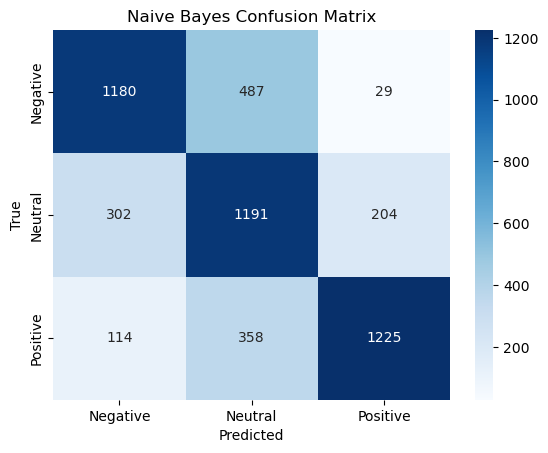

AUC Score (Multi-class): 0.8491


C:\Users\JISNA\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1146: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\JISNA\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1146: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\JISNA\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1146: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


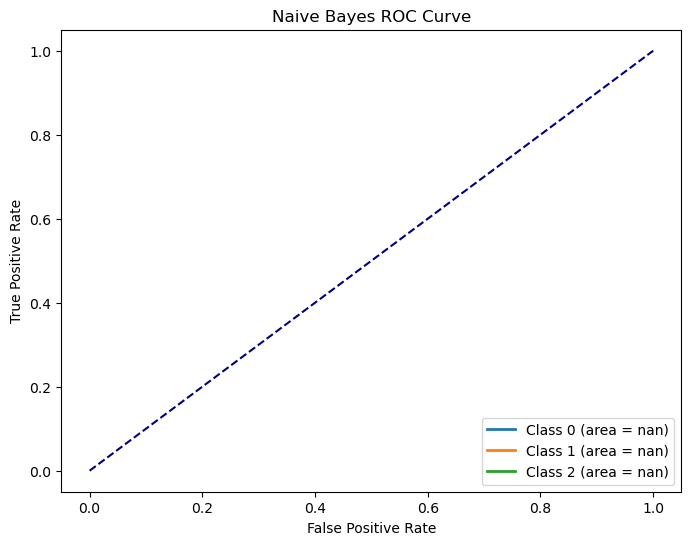

In [35]:
# from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict probabilities
y_proba_1 = nb_model_1.predict_proba(X_test)

# Plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.show()

# Plot ROC Curve
def plot_roc_curve(y_true, y_probnjnjkna, n_classes, title="ROC Curve"):
    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve((y_true == i).astype(int), y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curves
    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {i} (area = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()

# Confusion Matrix
print("Confusion Matrix:")
plot_confusion_matrix(y_test, y_pred_1, title="Naive Bayes Confusion Matrix")

# AUC
if y_proba_1.shape[1] > 1:  # Multi-class AUC
    auc_score = roc_auc_score(y_test, y_proba_1, multi_class="ovr")
    print(f"AUC Score (Multi-class): {auc_score:.4f}")
    plot_roc_curve(y_test, y_proba_1, n_classes=y_proba_1.shape[1], title="Naive Bayes ROC Curve")
else:  # Binary classification
    auc_score = roc_auc_score(y_test, y_proba_1[:, 1])
    print(f"AUC Score (Binary): {auc_score:.4f}")
    fpr, tpr, _ = roc_curve(y_test, y_proba_1[:, 1])
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.show()


### Model 2: SVM using TF-IDF Vectors (Unigram + Bigram)

Model 2 (SVM with TF-IDF Vectors) Classification Report:
               precision    recall  f1-score   support

    Negative       0.80      0.79      0.80      1696
     Neutral       0.67      0.71      0.69      1697
    Positive       0.85      0.81      0.83      1697

    accuracy                           0.77      5090
   macro avg       0.77      0.77      0.77      5090
weighted avg       0.77      0.77      0.77      5090



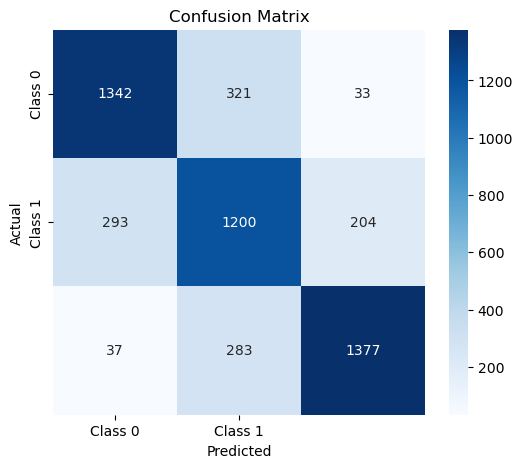

ValueError: multiclass format is not supported

In [36]:
# TF-IDF Vectorizer (Unigram + Bigram)
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2))  # Unigram + Bigram

# SVM Model
svm_model_2 = make_pipeline(tfidf_vectorizer, SVC(kernel='linear', probability=True))

# Train the model
svm_model_2.fit(X_train, y_train)

# Predict and evaluate
y_pred_2 = svm_model_2.predict(X_test)
print("Model 2 (SVM with TF-IDF Vectors) Classification Report:\n", classification_report(y_test, y_pred_2))

# 1. Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_2)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 2. AUC (Area Under the Curve)
y_prob_2 = svm_model_2.predict_proba(X_test)[:, 1]  # Get probabilities for class 1
fpr, tpr, thresholds = roc_curve(y_test, y_prob_2)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# 3. Model Configuration
print("\nModel Configuration:")
print(svm_model_2)

# If you want to display system configuration (e.g., Python version, memory usage)
import platform
import os
import psutil

print("\nSystem Configuration:")
print(f"Python version: {platform.python_version()}")
print(f"System: {platform.system()} {platform.release()}")
print(f"Processor: {platform.processor()}")
print(f"RAM: {psutil.virtual_memory().total / (1024 ** 3):.2f} GB")


### Model 3: Naive Bayes using TF-IDF Vectors (Unigram + Bigram)

Model Classification Report:
               precision    recall  f1-score   support

    Negative       0.76      0.75      0.76      1696
     Neutral       0.64      0.69      0.67      1697
    Positive       0.84      0.79      0.81      1697

    accuracy                           0.74      5090
   macro avg       0.75      0.74      0.75      5090
weighted avg       0.75      0.74      0.75      5090



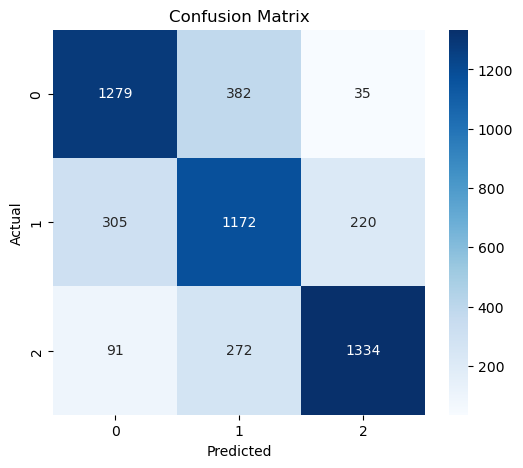

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# TF-IDF Vectorizer with feature limits
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),  # Unigram + Bigram
    max_features=10000,  # Limit to top 10,000 features
    min_df=5,            # Exclude terms that appear in fewer than 5 documents
    max_df=0.95          # Exclude terms that appear in more than 95% of documents
)

# Naive Bayes Model with TF-IDF Vectors
nb_model = make_pipeline(tfidf_vectorizer, MultinomialNB())

# Train the model
nb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = nb_model.predict(X_test)
print("Model Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# # AUC (Area Under the Curve)
# y_prob = nb_model.predict_proba(X_test)[:, 1]  # Get probabilities for class 1
# fpr, tpr, thresholds = roc_curve(y_test, y_prob)
# roc_auc = auc(fpr, tpr)

# plt.figure(figsize=(6, 5))
# plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
# plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC)')
# plt.legend(loc='lower right')
# plt.show()


### Model 4: SVM using Count Vectors (Unigram + Bigram)


In [ ]:
# Count Vectorizer (Unigram + Bigram)
count_vectorizer_bigram = CountVectorizer(ngram_range=(1, 2))  # Unigram + Bigram

# SVM Model with Count Vectors (Unigram + Bigram)
svm_model_4 = make_pipeline(count_vectorizer_bigram, SVC(kernel='linear', probability=True))

# Train the model
svm_model_4.fit(X_train, y_train)

# Predict and evaluate
y_pred_4 = svm_model_4.predict(X_test)
print("Model 4 (SVM with Count Vectors) Classification Report:\n", classification_report(y_test, y_pred_4))

# 1. Confusion Matrix
conf_matrix_4 = confusion_matrix(y_test, y_pred_4)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_4, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# # 2. AUC (Area Under the Curve)
# y_prob_4 = svm_model_4.predict_proba(X_test)[:, 1]  # Get probabilities for class 1
# fpr_4, tpr_4, thresholds_4 = roc_curve(y_test, y_prob_4)
# roc_auc_4 = auc(fpr_4, tpr_4)

# plt.figure(figsize=(6, 5))
# plt.plot(fpr_4, tpr_4, color='blue', lw=2, label=f'ROC curve (area = {roc_auc_4:.2f})')
# plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC)')
# plt.legend(loc='lower right')
# plt.show()

# # 3. Model Configuration
# print("\nModel Configuration:")
# print(svm_model_4)


### Model 5

In [ ]:
# Smaller vocabulary (e.g., top 10,000 features)
count_vectorizer_small = CountVectorizer(ngram_range=(1, 2), max_features=10000)

X_train_small = count_vectorizer_small.fit_transform(X_train)
X_test_small = count_vectorizer_small.transform(X_test)

# Naive Bayes with Smaller Vocabulary
nb_model_5 = MultinomialNB()
nb_model_5.fit(X_train_small, y_train)

# Predict and evaluate
y_pred_5 = nb_model_5.predict(X_test_small)
print("Model 5 with Smaller Vocabulary Classification Report:\n", classification_report(y_test, y_pred_5))

# 1. Confusion Matrix
conf_matrix_5 = confusion_matrix(y_test, y_pred_5)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_5, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# # 2. AUC (Area Under the Curve)
# y_prob_5 = nb_model_5.predict_proba(X_test_small)[:, 1]  # Get probabilities for class 1
# fpr_5, tpr_5, thresholds_5 = roc_curve(y_test, y_prob_5)
# roc_auc_5 = auc(fpr_5, tpr_5)

# plt.figure(figsize=(6, 5))
# plt.plot(fpr_5, tpr_5, color='blue', lw=2, label=f'ROC curve (area = {roc_auc_5:.2f})')
# plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC)')
# plt.legend(loc='lower right')
# plt.show()

# # 3. Model Configuration
# print("\nModel Configuration:")
# print(nb_model_5)
